# 01 - Macro Data Pipeline and Regime Classification

**Purpose:** download monthly growth and inflation data for the US and the Euro area, and classify each month into one of four macro regimes.

**Outputs:**
- `data/macro_data.csv`: monthly growth and inflation, US and Euro area
- `data/regimes.csv`: monthly regime classification for both regions

**Period:** January 1997 – latest month available for all series

## 1. Data sources

| Series | Region | Source | Measure |
|---|---|---|---|
| CPI, all items (`CPIAUCSL`) | US | FRED | Inflation, year-on-year % |
| HICP, overall index (`HICP.M.U2.N.000000.4D0.ANR`) | Euro area | ECB Data Portal | Inflation, year-on-year % |
| Industrial production (`INDPRO`) | US | FRED | Growth, year-on-year % |
| Industrial production excl. construction (`STBS.M.I10.Y.PROD.NS0020.4D0.N.IX`) | Euro area | ECB Data Portal | Growth, year-on-year % |

Headline inflation is used rather than core, because energy shocks (such as 2022) are exactly the regimes the model needs to capture.

Industrial production is used for growth in both regions, so growth is measured the same way in the US and the Euro area. GDP was not used because it is quarterly, published late and heavily revised.

**Missing data:** October 2025 US CPI was never published because of the federal government shutdown. The missing index value is filled by linear interpolation between September and November 2025.


In [1]:
import pandas as pd
import numpy as np

url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=CPIAUCSL"
cpi = pd.read_csv(url, index_col=0, parse_dates=True)
cpi["CPIAUCSL"] = cpi["CPIAUCSL"].interpolate(limit_area="inside")

cpi["inflation_yoy"] = cpi["CPIAUCSL"].pct_change(12) * 100
cpi.loc["2025-08":"2025-12"]

,CPIAUCSL,inflation_yoy
observation_date,,
2025-08-01,323.291,2.938592
2025-09-01,324.245,3.022572
2025-10-01,324.654,2.858718
2025-11-01,325.063,2.696444
2025-12-01,326.031,2.653304


### Euro area inflation

The ECB provides the annual rate of change directly, so no calculation is needed.

**Note:** in February 2026, Eurostat introduced major methodological changes to the HICP (new ECOICOP 2 classification, base year 2025 = 100). The ECB discontinued the old `ICP` dataset, which ended in December 2025, and replaced it with the new `HICP` dataset. The pipeline uses the new series, which covers December 1996 to the present.

In [2]:
import requests
import io

url_hicp = "https://data-api.ecb.europa.eu/service/data/HICP/M.U2.N.000000.4D0.ANR?format=csvdata"
response = requests.get(url_hicp, timeout=30)
response.raise_for_status()
hicp_raw = pd.read_csv(io.StringIO(response.text))

hicp = hicp_raw[["TIME_PERIOD", "OBS_VALUE"]].copy()
hicp.columns = ["date", "ea_inflation_yoy"]
hicp["date"] = pd.to_datetime(hicp["date"])
hicp = hicp.set_index("date").sort_index()
hicp.tail(15)

,ea_inflation_yoy
date,
2025-07-01,2.0
2025-08-01,2.0
2025-09-01,2.2
2025-10-01,2.1
2025-11-01,2.1
2025-12-01,2.0
2026-01-01,1.7
2026-02-01,1.9
2026-03-01,2.6


### Euro area growth

The ECB provides an index, so year-on-year growth is calculated in the same way as for the US (`pct_change(12)`). Data is sorted by date first, because the calculation compares each row with the row 12 positions above.

The series uses a **fixed composition** (all 21 current euro area members across the whole history), while the HICP uses a **changing composition** (countries included as they joined). The difference is small and does not affect the results.

In [3]:
url_ip = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=INDPRO"
ip = pd.read_csv(url_ip, index_col=0, parse_dates=True)

ip["us_growth_yoy"] = ip["INDPRO"].pct_change(12) * 100
ip.tail(15)

,INDPRO,us_growth_yoy
observation_date,,
2025-06-01,101.4785,0.579321
2025-07-01,101.8940,1.918766
2025-08-01,101.6247,1.188678
2025-09-01,101.6680,1.863170
2025-10-01,101.2195,1.759333
2025-11-01,101.0344,1.754312
2025-12-01,101.4941,1.162994
2026-01-01,101.0388,0.973470
2026-02-01,101.9053,0.797236


In [4]:
url_ea_ip = "https://data-api.ecb.europa.eu/service/data/STBS/M.I10.Y.PROD.NS0020.4D0.N.IX?format=csvdata"
response = requests.get(url_ea_ip, timeout=30)
response.raise_for_status()
ea_ip_raw = pd.read_csv(io.StringIO(response.text))

ea_ip = ea_ip_raw[["TIME_PERIOD", "OBS_VALUE"]].copy()
ea_ip.columns = ["date", "ea_ip_index"]
ea_ip["date"] = pd.to_datetime(ea_ip["date"])
ea_ip = ea_ip.set_index("date").sort_index()
ea_ip["ea_ip_growth_yoy"] = ea_ip["ea_ip_index"].pct_change(12) * 100
ea_ip.tail(15)

,ea_ip_index,ea_ip_growth_yoy
date,,
2025-05-01,98.9,3.020833
2025-06-01,98.6,0.921187
2025-07-01,98.5,1.546392
2025-08-01,98.3,0.820513
2025-09-01,98.1,1.447777
2025-10-01,98.4,1.547988
2025-11-01,98.7,1.857585
2025-12-01,98.4,1.968912
2026-01-01,97.2,-0.917431


### Euro area growth: Economic Sentiment Indicator

Industrial production is published about six weeks after the month ends and is noisy. The European Commission's Economic Sentiment Indicator (ESI) is published at the end of the month it describes, and covers industry (40%), services (30%), consumers (20%), retail (5%) and construction (5%).

Source: Eurostat, dataset `ei_bssi_m_r2`, series `M.BS-ESI-I.SA.EA21` (euro area, 21 countries, seasonally adjusted). The `EA20` series ended in December 2025, when Bulgaria joined the euro.

The ESI is a survey score with a long-term average of 100, not an output index, so no growth rate is calculated: the 12-month rule is applied to its level directly.

In [5]:
url_esi = "https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/ei_bssi_m_r2/M.BS-ESI-I.SA.?format=SDMX-CSV"
response = requests.get(url_esi, timeout=60)
response.raise_for_status()
esi_raw = pd.read_csv(io.StringIO(response.text))

esi_raw["geo"].unique()

<StringArray>
[       'AL',        'AT',        'BE',        'BG',        'CY',        'CZ',
        'DE',        'DK',      'EA20',      'EA21',        'EE',        'EL',
        'ES', 'EU27_2020',        'FI',        'FR',        'HR',        'HU',
        'IE',        'IT',        'LT',        'LU',        'LV',        'ME',
        'MK',        'MT',        'NL',        'PL',        'PT',        'RO',
        'RS',        'SE',        'SI',        'SK',        'TR']
Length: 35, dtype: str

In [6]:
for area in ["EA20", "EA21"]:
    s = esi_raw.loc[esi_raw["geo"] == area].set_index("TIME_PERIOD")["OBS_VALUE"].dropna()
    print(area, "|", s.index.min(), "to", s.index.max(), "|", len(s), "months")

EA20 | 1980-01 to 2025-12 | 552 months
EA21 | 1980-01 to 2026-09 | 561 months


In [7]:
esi = esi_raw.loc[esi_raw["geo"] == "EA21", ["TIME_PERIOD", "OBS_VALUE"]].copy()
esi.columns = ["date", "ea_esi"]
esi["date"] = pd.to_datetime(esi["date"])
esi = esi.set_index("date").sort_index()["ea_esi"].dropna()

esi.tail()

date
2026-05-01    94.3
2026-06-01    95.6
2026-07-01    97.1
2026-08-01    98.4
2026-09-01    97.9
Name: ea_esi, dtype: float64

In [8]:
compare = pd.DataFrame({
    "ea_ip_growth": ea_ip["ea_ip_growth_yoy"],
    "ea_esi": esi,
}).loc["1997":].dropna()

for col in compare.columns:
    avg_12m = compare[col].rolling(12).mean()
    rising = (compare[col] > avg_12m).where(avg_12m.notna()).dropna().astype(bool)
    switches = (rising != rising.shift(1)).iloc[1:].sum()
    print(f"{col}: {switches} switches, average regime {len(rising) / (switches + 1):.1f} months")

ea_ip_growth: 55 switches, average regime 6.1 months
ea_esi: 42 switches, average regime 8.0 months


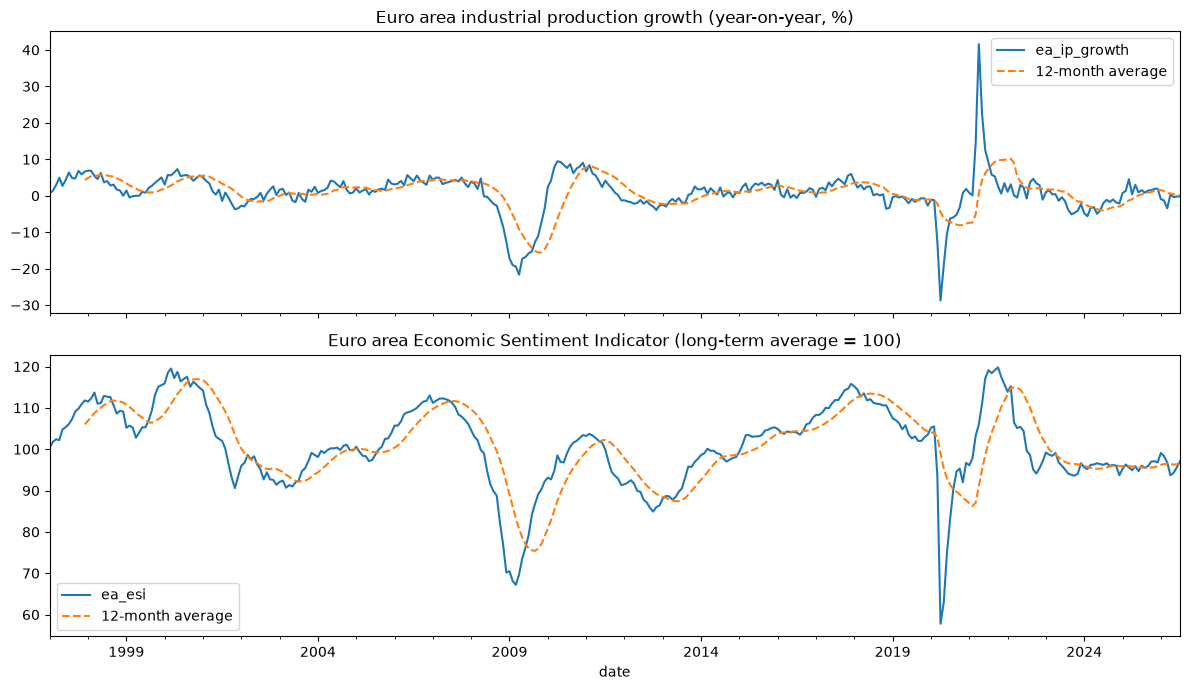

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

compare["ea_ip_growth"].plot(ax=axes[0], title="Euro area industrial production growth (year-on-year, %)")
compare["ea_ip_growth"].rolling(12).mean().plot(ax=axes[0], linestyle="--", label="12-month average")

compare["ea_esi"].plot(ax=axes[1], title="Euro area Economic Sentiment Indicator (long-term average = 100)")
compare["ea_esi"].rolling(12).mean().plot(ax=axes[1], linestyle="--", label="12-month average")

for ax in axes:
    ax.legend()

plt.tight_layout()
plt.show()

In [10]:
check = compare.loc["2022-06":"2022-12"].copy()
check["esi_12m_avg"] = compare["ea_esi"].rolling(12).mean()
check

,ea_ip_growth,ea_esi,esi_12m_avg
date,,,
2022-06-01,2.302302,104.4,113.341667
2022-07-01,-0.789733,99.6,111.716667
2022-08-01,3.636364,98.6,110.066667
2022-09-01,4.641776,95.1,108.066667
2022-10-01,3.423968,94.1,105.925000
2022-11-01,2.900000,95.4,104.083333
2022-12-01,-1.078431,97.1,102.533333


## 2. Combined table

The four series are combined into one monthly table. Only months with data for all four series are kept, so:
- the table **starts** when the shortest series starts (Euro area HICP, 1997)
- the table **ends** at the latest month published for all series

Euro area industrial production is published about six weeks after the month ends, later than the other series. **The model can only know as much as its slowest data.** This publication lag will be applied in the backtest, so the model never uses data before it was actually available.

In [11]:
data = pd.concat([
    cpi["inflation_yoy"].rename("us_inflation"),
    hicp["ea_inflation_yoy"].rename("ea_inflation"),
    ip["us_growth_yoy"].rename("us_growth"),
    ea_ip["ea_ip_growth_yoy"].rename("ea_growth")
], axis=1)

data=data.dropna()
data.tail(15)

C:\Users\Cobi\AppData\Local\Temp\ipykernel_33256\932804218.py:1: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  data = pd.concat([


,us_inflation,ea_inflation,us_growth,ea_growth
2025-05-01,2.377265,1.9,0.101623,3.020833
2025-06-01,2.680454,2.0,0.579321,0.921187
2025-07-01,2.742618,2.0,1.918766,1.546392
2025-08-01,2.938592,2.0,1.188678,0.820513
2025-09-01,3.022572,2.2,1.863170,1.447777
2025-10-01,2.858718,2.1,1.759333,1.547988
2025-11-01,2.696444,2.1,1.754312,1.857585
2025-12-01,2.653304,2.0,1.162994,1.968912
2026-01-01,2.391201,1.7,0.973470,-0.917431
2026-02-01,2.434004,1.9,0.797236,-1.314459


## Chart ploting

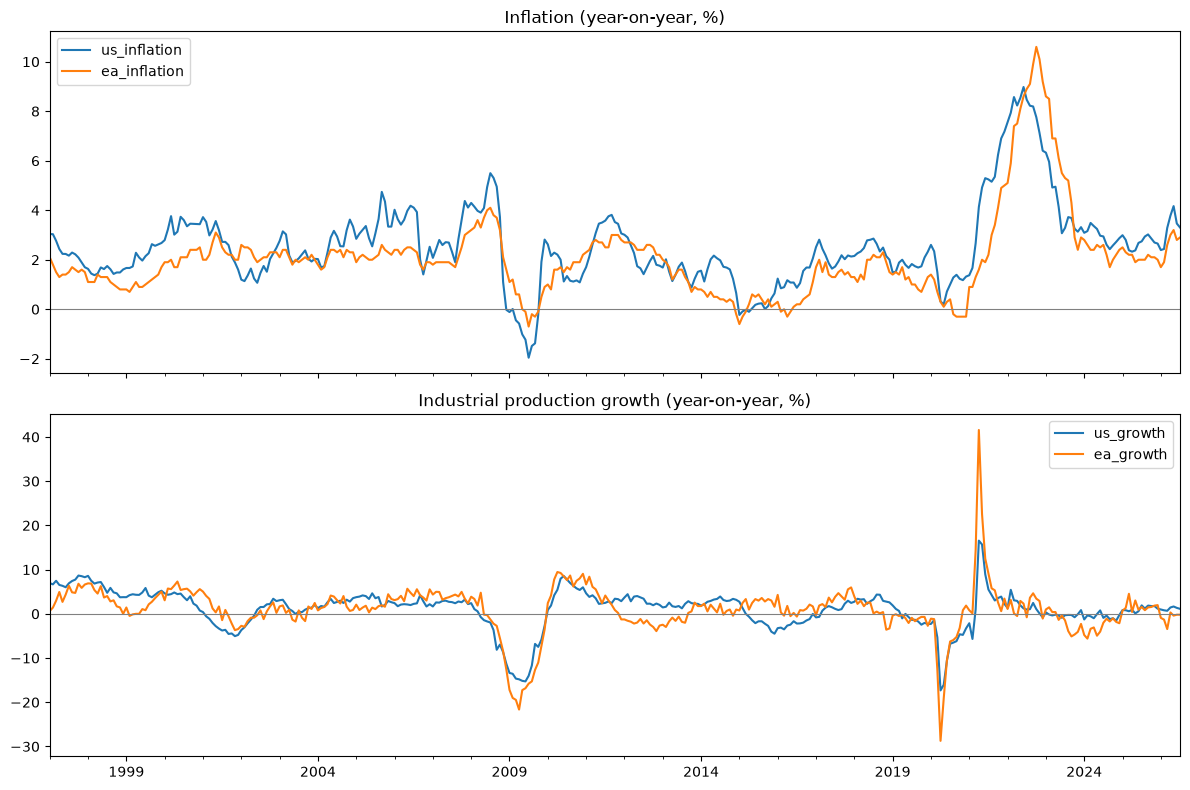

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

data[["us_inflation", "ea_inflation"]].plot(ax=axes[0], title="Inflation (year-on-year, %)")
data[["us_growth", "ea_growth"]].plot(ax=axes[1], title="Industrial production growth (year-on-year, %)")

for ax in axes:
    ax.axhline(0, color="grey", linewidth=0.8)

plt.tight_layout()
plt.show()

In [13]:
from pathlib import Path

Path("../data").mkdir(parents=True, exist_ok=True)
data.to_csv("../data/macro_data.csv")

## 3. Rising or falling?

Each month, growth and inflation are classified as **rising** or **falling**. The model uses the **change** rather than the level: markets already price in the level, so returns respond to whether the economy is accelerating or slowing.

Two rules were tested:
- **12-month rule (main model):** rising if the current value is above its average of the past 12 months
- **3-month rule (comparison):** rising if the current value is above its value 3 months earlier

**Handling missing data:** at the start of the sample, the comparison value does not exist yet. In pandas, comparing a number with a missing value returns `False`, which would silently classify those months as "falling". These months are set to missing and removed instead.

In [14]:
regimes = pd.DataFrame(index=data.index)

for col in ["us_growth", "us_inflation", "ea_growth", "ea_inflation"]:
    avg_12m = data[col].rolling(12).mean()
    rising = data[col] > avg_12m
    regimes[col + "_rising"] = rising.where(avg_12m.notna())

regimes = regimes.dropna().astype(bool)
regimes.head()

,us_growth_rising,us_inflation_rising,ea_growth_rising,ea_inflation_rising
1997-12-01,True,False,True,False
1998-01-01,True,False,True,False
1998-02-01,False,False,True,False
1998-03-01,False,False,False,False
1998-04-01,False,False,False,False


In [15]:
regimes_3m = pd.DataFrame(index=data.index)

for col in ["us_growth", "us_inflation", "ea_growth", "ea_inflation"]:
    value_3m_ago = data[col].shift(3)
    rising_3m = data[col] > value_3m_ago
    regimes_3m[col + "_rising"] = rising_3m.where(value_3m_ago.notna())

regimes_3m = regimes_3m.dropna().astype(bool)
regimes_3m.head()

,us_growth_rising,us_inflation_rising,ea_growth_rising,ea_inflation_rising
1997-04-01,False,False,True,False
1997-05-01,False,False,True,False
1997-06-01,False,False,True,False
1997-07-01,True,False,True,True
1997-08-01,True,True,True,True


## How many times does each method switch

In [16]:
common_start = regimes.index.min()
r12 = regimes
r3 = regimes_3m.loc[common_start:]

switches_12m = (r12 != r12.shift(1)).iloc[1:].sum()
switches_3m = (r3 != r3.shift(1)).iloc[1:].sum()

comparison = pd.DataFrame({"12-month": switches_12m, "3-month": switches_3m})
comparison

,12-month,3-month
us_growth_rising,43,85
us_inflation_rising,51,84
ea_growth_rising,55,107
ea_inflation_rising,41,80


In [17]:
comparison["12m_avg_length"] = len(r12) / (comparison["12-month"] + 1)
comparison["3m_avg_length"] = len(r3) / (comparison["3-month"] + 1)

comparison.round(1)

,12-month,3-month,12m_avg_length,3m_avg_length
us_growth_rising,43,85,7.8,4.0
us_inflation_rising,51,84,6.6,4.0
ea_growth_rising,55,107,6.1,3.2
ea_inflation_rising,41,80,8.2,4.2


### Stability of the two rules

| Variable | Switches (12m) | Switches (3m) | Avg length, months (12m) | Avg length, months (3m) |
|---|---|---|---|---|
| US growth | 43 | 83 | 7.8 | 4.1 |
| US inflation | 51 | 84 | 6.6 | 4.0 |
| EA growth | 55 | 107 | 6.1 | 3.2 |
| EA inflation | 41 | 80 | 8.2 | 4.2 |

The 3-month rule produces regimes lasting only 3–4 months on average, too short to reflect genuine economic phases. The 12-month rule roughly halves the number of switches. **Trade-off:** the 12-month rule filters out noise but recognises turning points later. Both rules will be compared in the backtest.

Euro area growth is the noisiest series under both rules.

## 4. Macro regimes

Growth and inflation are combined into four regimes:

| | Inflation falling | Inflation rising |
|---|---|---|
| **Growth rising** | Goldilocks | Overheating |
| **Growth falling** | Slowdown | Stagflation |~

Regimes are built separately for each region, so a missing month in one region does not remove it from the other. The Euro area uses the Economic Sentiment Indicator for growth (see Section 1); the comparison in Section 3 was carried out on industrial production.

In [18]:
def build_regimes(growth, inflation, prefix):
    df = pd.concat([growth.rename("growth"), inflation.rename("inflation")], axis=1).dropna()

    out = pd.DataFrame(index=df.index)
    for col in ["growth", "inflation"]:
        avg_12m = df[col].rolling(12).mean()
        out[f"{prefix}_{col}_rising"] = (df[col] > avg_12m).where(avg_12m.notna())
    out = out.dropna().astype(bool)

    g = out[f"{prefix}_growth_rising"]
    i = out[f"{prefix}_inflation_rising"]
    conditions = [g & ~i, g & i, ~g & ~i, ~g & i]
    labels = ["Goldilocks", "Overheating", "Slowdown", "Stagflation"]
    out[f"{prefix}_regime"] = np.select(conditions, labels, default="Unknown")
    return out

us_regimes = build_regimes(ip["us_growth_yoy"], cpi["inflation_yoy"], "us")
ea_regimes = build_regimes(esi, hicp["ea_inflation_yoy"], "ea")

regimes = pd.concat([us_regimes, ea_regimes], axis=1).loc["1997":]
regimes.to_csv("../data/regimes.csv")

print("US:", us_regimes.index.min(), "to", us_regimes.index.max())
print("EA:", ea_regimes.index.min(), "to", ea_regimes.index.max())


US: 1948-12-01 00:00:00 to 2026-08-01 00:00:00
EA: 1997-12-01 00:00:00 to 2026-09-01 00:00:00


In [19]:
regimes.loc["2025-08":"2025-12", ["us_regime", "ea_regime"]]

,us_regime,ea_regime
2025-08-01,Overheating,Slowdown
2025-09-01,Overheating,Overheating
2025-10-01,Overheating,Goldilocks
2025-11-01,Goldilocks,Goldilocks
2025-12-01,Goldilocks,Goldilocks


In [20]:
regimes.loc["2022-01":"2022-12", ["us_regime", "ea_regime"]]

,us_regime,ea_regime
2022-01-01,Stagflation,Overheating
2022-02-01,Stagflation,Overheating
2022-03-01,Stagflation,Stagflation
2022-04-01,Stagflation,Stagflation
2022-05-01,Stagflation,Stagflation
2022-06-01,Stagflation,Stagflation
2022-07-01,Stagflation,Stagflation
2022-08-01,Stagflation,Stagflation
2022-09-01,Stagflation,Stagflation
2022-10-01,Slowdown,Stagflation


## 5. Sanity checks

- **2020 (COVID):** both regions classified as **Slowdown** in spring 2020.
- **2022 (energy shock):** the Euro area moves from Overheating to **Stagflation in March 2022**, the month after Russia's invasion of Ukraine, and stays there for the rest of the year. With industrial production as the growth measure, the model had wrongly classified August–November 2022 as Overheating; the Economic Sentiment Indicator corrects this. The US is in Stagflation until September 2022, then Slowdown, about four months after US inflation peaked, showing the lag of the 12-month rule.
- **October 2025:** present for both regions after interpolating the missing US CPI value.
## Limitations

- **Lag:** the 12-month rule confirms turning points several months after they happen.
- **US growth** is still measured by industrial production, which covers only part of the economy and is published about two weeks after the month ends.
- **Revisions:** the data used is the latest revised version, not what was available at the time. Real-time (vintage) data would be more realistic.
- **Industrial production** covers only part of the economy; services are not captured.